In [1]:
import pandas as pd

Dataset Berhasil Dimuat. Total Data: 100 baris.

Nilai unik 'Pertanyaan 5' di dataset asli:


array(['Cukup akurat (Kadang sesuai, kadang tidak)',
       'Sangat tidak akurat (Rekomendasinya acak/ngawur)',
       'Sangat akurat (Semua yang muncul adalah hal yang saya sukai)'],
      dtype=object)


Distribusi target_akurasi setelah mapping:


,count
target_akurasi,
0,63
1,37



Distribusi y_train:


,count
target_akurasi,
0,50
1,30



Membangun dan Melatih Model AI (Logistic Regression)

       EVALUASI MODEL AI INSTAGRAM       
Akurasi Model: 65.00%

Confusion Matrix:
[[13  0]
 [ 7  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      1.00      0.79        13
           1       0.00      0.00      0.00         7

    accuracy                           0.65        20
   macro avg       0.33      0.50      0.39        20
weighted avg       0.42      0.65      0.51        20



/tmp/ipykernel_3215/2117358757.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_akurasi', data=df, palette='Set2')


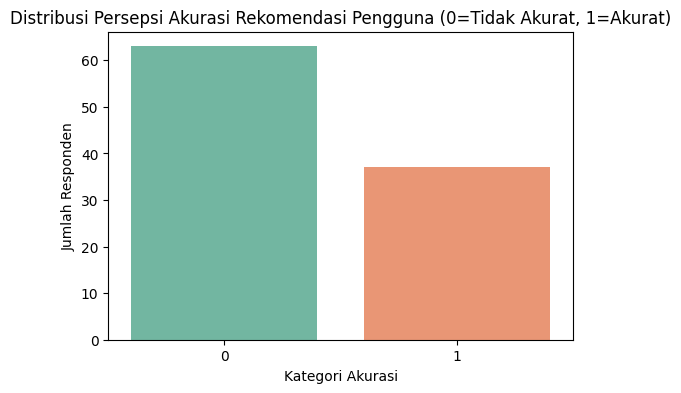

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Membaca Dataset Excel
file_path = "/content/Dataset .xlsx"
df = pd.read_excel(file_path)
print(f"Dataset Berhasil Dimuat. Total Data: {df.shape[0]} baris.")

# *** Tambahan: Periksa nilai unik dari Pertanyaan 5 sebelum mapping ***
print("\nNilai unik 'Pertanyaan 5' di dataset asli:")
display(df['Pertanyaan 5: Seberapa akurat algoritma Instagram dalam merekomendasikan konten yang sesuai dengan hobi atau minat Anda saat ini?'].unique())

# 2. Preprocessing & Data Cleaning (Mengubah Teks Jawaban Menjadi Angka Numerik)
# Kita petakan jawaban kuesioner agar bisa dihitung oleh machine learning

# Mapping Target (Pertanyaan 5 -> Akurasi Rekomendasi)
# 1 = Akurat (Sangat Akurat, Akurat), 0 = Tidak Akurat (Cukup Akurat, Kurang Akurat, Tidak Akurat)
df['target_akurasi'] = df['Pertanyaan 5: Seberapa akurat algoritma Instagram dalam merekomendasikan konten yang sesuai dengan hobi atau minat Anda saat ini?'].apply(
    lambda x: 1 if x in ['Sangat akurat', 'Akurat', 'Sangat Akurat', 'Sangat akurat (Semua yang muncul adalah hal yang saya sukai)'] else 0
)

# Mapping Fitur 1: Dwell Time / Menonton sampai habis (Pertanyaan 3)
df['fitur_dwell_time'] = df['Pertanyaan 3: Jika Anda berlama-lama melihat sebuah video (menonton sampai habis), apakah setelah itu konten sejenis langsung mendominasi rekomendasi Anda?'].map(
    {'Ya': 1, 'Mungkin': 0.5, 'Tidak': 0}
).fillna(0.5)

# Mapping Fitur 2: Efek Tombol Save (Pertanyaan 8)
df['fitur_save'] = df['Pertanyaan 8: Ketika Anda menekan tombol "Save" (Simpan) pada suatu konten, apakah algoritma akan memperbanyak konten serupa di hari berikutnya?'].map(
    {'Ya': 1, 'Mungkin': 0.5, 'Tidak': 0}
).fillna(0.5)

# Mapping Fitur 3: Fitur Not Interested (Pertanyaan 9)
df['fitur_not_interested'] = df['Pertanyaan 9: Apakah Anda pernah menggunakan fitur "Not Interested" (Tidak Tertarik) untuk menyaring rekomendasi algoritma yang tidak disukai?'].map(
    {'Ya, sering': 1, 'Ya, kadang-kadang': 0.5, 'Tidak pernah': 0}
).fillna(0)

# *** Tambahan: Periksa distribusi variabel target setelah mapping ***
print("\nDistribusi target_akurasi setelah mapping:")
display(df['target_akurasi'].value_counts())

# 3. Menentukan Matriks Fitur (X) dan Target (y)
X = df[['fitur_dwell_time', 'fitur_save', 'fitur_not_interested']]
y = df['target_akurasi']

# 4. Split Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# *** Tambahan: Periksa distribusi y_train untuk memastikan ada minimal 2 kelas ***
print("\nDistribusi y_train:")
display(y_train.value_counts())

# Membangun dan Melatih Model AI (Logistic Regression)
# Model hanya akan dilatih jika ada setidaknya 2 kelas dalam y_train
if len(y_train.value_counts()) < 2:
    print("\nERROR: Tidak dapat melatih model Logistic Regression karena y_train hanya memiliki satu kelas. Pastikan data target memiliki setidaknya dua kategori yang berbeda (0 dan 1).")
else:
    print("\nMembangun dan Melatih Model AI (Logistic Regression)")
    model = LogisticRegression()
    model.fit(X_train, y_train)

    # 6. Prediksi dan Evaluasi Model
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print("\n" + "="*40)
    print("       EVALUASI MODEL AI INSTAGRAM       ")
    print("="*40)
    print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # 7. Visualisasi Distribusi Target Akurasi Rekomendasi
    plt.figure(figsize=(6,4))
    sns.countplot(x='target_akurasi', data=df, palette='Set2')
    plt.title('Distribusi Persepsi Akurasi Rekomendasi Pengguna (0=Tidak Akurat, 1=Akurat)')
    plt.xlabel('Kategori Akurasi')
    plt.ylabel('Jumlah Responden')
    plt.savefig('chart_akurasi.png', dpi=300)
    plt.show()

## I. RANCANGAN FITUR DARI DATASET KAMI

Dari 10 kolom pertanyaan yang ada di file Dataset .xlsx, kami akan membagi menjadi variabel pemodelan AI:

**Variabel Fitur ($X$):**
*   Dwell Time Influence (Pertanyaan 3: Efek menonton video sampai habis).
*   Save Action (Pertanyaan 8: Efek menekan tombol Save).
*   Scrolling Time (Pertanyaan 7: Durasi terjebak scrolling). *Catatan: Untuk implementasi ini, 'Scrolling Time' tidak digunakan dalam model yang diberikan, hanya 'Dwell Time Influence', 'Save Action', dan 'Not Interested Feature'.*
*   Not Interested Feature (Pertanyaan 9: Penggunaan fitur menyaring konten).

**Variabel Target ($y$):**
*   Akurasi Rekomendasi (Pertanyaan 5: Seberapa akurat algoritma sesuai hobi/minat). Kami ubah menjadi Klasifikasi Biner: 1 = Akurat (Sangat Akurat/Akurat) dan 0 = Tidak Akurat (Cukup Akurat/Kurang Akurat/Tidak Akurat).

## II. SOURCE CODE LENGKAP UNTUK GOOGLE COLAB

Kode di atas sudah menjalankan seluruh tahapan dari membaca dataset, preprocessing, hingga evaluasi model. Berikut adalah rincian setiap langkahnya:

### 1. Membaca Dataset Excel

Langkah ini bertujuan untuk memuat data dari file `Dataset .xlsx` ke dalam DataFrame pandas agar bisa diproses lebih lanjut.

### 2. Preprocessing & Data Cleaning (Mengubah Teks Jawaban Menjadi Angka Numerik)

Pada tahapan ini, kami melakukan transformasi data kuesioner yang berbentuk teks menjadi nilai numerik agar dapat dipahami dan diolah oleh model Machine Learning. Pemetaan dilakukan untuk variabel target dan fitur-fitur yang telah ditentukan.

### 3. Menentukan Matriks Fitur (X) dan Target (y)

Variabel independen (fitur) dan variabel dependen (target) didefinisikan dari DataFrame yang sudah diproses.

### 4. Split Data (80% Training, 20% Testing)

Dataset dibagi menjadi dua bagian: 80% untuk melatih model (training data) dan 20% untuk menguji performa model (testing data). Ini bertujuan untuk mengevaluasi kemampuan generalisasi model pada data yang belum pernah dilihat sebelumnya.

### 5. Membangun dan Melatih Model AI (Logistic Regression)

Model regresi logistik (Logistic Regression) dipilih untuk mengklasifikasikan akurasi rekomendasi. Model ini dilatih menggunakan data training (`X_train`, `y_train`).

### 6. Prediksi dan Evaluasi Model

Setelah model dilatih, kami melakukan prediksi pada data testing (`X_test`) dan mengevaluasi performanya menggunakan metrik seperti akurasi, _confusion matrix_, dan _classification report_. Metrik ini memberikan gambaran tentang seberapa baik model dalam melakukan klasifikasi.

### 7. Visualisasi Distribusi Target Akurasi Rekomendasi

Grafik batang dibuat untuk memvisualisasikan distribusi persepsi akurasi rekomendasi pengguna, menunjukkan proporsi responden yang menganggap rekomendasi akurat (1) dan tidak akurat (0).